<a href="https://colab.research.google.com/github/shriyashshitole/simple-ARIMA/blob/main/ARIMAv4_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ARIMA STOCK PRICE FORECASTING MODEL

#### Author: **Shriniwas Shitole**
#### Institution: Pune Institute of Business Management
#### Course: Time Series Analysis and Forecasting
#### Model: ARIMA (AutoRegressive Integrated Moving Average)

# SECTION 1: INSTALLATION & IMPORTS

!pip install yfinance statsmodels -q

In [23]:
# Import libraries
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import yfinance as yf
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 100

print("✅ All libraries imported successfully!")
print("=" * 80)


✅ All libraries imported successfully!


# SECTION 2: CONFIGURATION - CUSTOMIZE YOUR ANALYSIS HERE

In [24]:
print("\n📊 CONFIGURATION SECTION - Customize Your Analysis Here")
print("=" * 80)

# Stock Configuration
STOCK_SYMBOL = 'AAPL'          # Stock ticker (e.g., 'AAPL', 'GOOGL', 'MSFT', 'TSLA', 'AMZN')
                               # Indian stocks: 'RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS'

# Data Configuration
TRAINING_DAYS = 365            # Number of historical days to use (e.g., 180, 365, 730)
FORECAST_DAYS = 30             # Number of days to predict (e.g., 7, 14, 30, 60, 90)

# Model Configuration
AUTO_ORDER = True              # True: Automatically find best parameters, False: Use manual order
MANUAL_ORDER = (1, 1, 1)       # Used only if AUTO_ORDER = False, format: (p, d, q)
MAX_P = 5                      # Maximum p value to test (increase for better results)
MAX_Q = 5                      # Maximum q value to test (increase for better results)

# Analysis Configuration
PERFORM_EVALUATION = True      # Perform train-test split evaluation
TEST_SIZE = 0.2                # Proportion of data for testing (0.2 = 20%)
SHOW_ACF_PACF = True           # Show ACF/PACF plots
ACF_PACF_LAGS = 40             # Number of lags to display in ACF/PACF

# Forecast Enhancement
USE_SIMULATION = True          # Use simulation for realistic variations
N_SIMULATIONS = 100            # Number of simulations (more = smoother but slower)
CONFIDENCE_LEVEL = 0.95        # Confidence level for intervals (0.95 = 95%)

# Visualization Configuration
PLOT_STYLE = 'detailed'        # 'detailed' or 'simple'
SAVE_RESULTS = True            # Save forecast to CSV file

# Logging Configuration
VERBOSE = True                 # Enable detailed logging

print(f"""
✓ Stock Symbol      : {STOCK_SYMBOL}
✓ Training Period   : {TRAINING_DAYS} days
✓ Forecast Horizon  : {FORECAST_DAYS} days
✓ Auto Order Search : {AUTO_ORDER}
✓ Max Parameters    : p={MAX_P}, q={MAX_Q}
✓ Use Simulation    : {USE_SIMULATION}
✓ Confidence Level  : {CONFIDENCE_LEVEL*100:.0f}%
""")
print("=" * 80)


📊 CONFIGURATION SECTION - Customize Your Analysis Here

✓ Stock Symbol      : AAPL
✓ Training Period   : 365 days
✓ Forecast Horizon  : 30 days
✓ Auto Order Search : True
✓ Max Parameters    : p=5, q=5
✓ Use Simulation    : True
✓ Confidence Level  : 95%



# SECTION 3: HELPER FUNCTIONS & LOGGING UTILITIES

In [25]:
def log_message(message, level="INFO"):
    """Enhanced logging with timestamps and icons"""
    if VERBOSE:
        timestamp = datetime.now().strftime('%H:%M:%S')
        symbols = {
            "INFO": "ℹ️",
            "SUCCESS": "✅",
            "WARNING": "⚠️",
            "ERROR": "❌",
            "PROCESS": "⚙️",
            "ANALYSIS": "📈",
            "RESULT": "📊"
        }
        symbol = symbols.get(level, "•")
        print(f"[{timestamp}] {symbol} {message}")

def print_header(title):
    """Print formatted section header"""
    print(f"\n{'=' * 80}")
    print(title.center(80))
    print(f"{'=' * 80}\n")

def print_separator():
    """Print separator line"""
    print(f"{'─' * 80}")

# SECTION 4: DATA FETCHING & PREPROCESSING

In [26]:
print_header("STEP 1: DATA FETCHING & PREPROCESSING")

log_message(f"Fetching {TRAINING_DAYS} days of data for {STOCK_SYMBOL}...", "PROCESS")

try:
    # Calculate date range
    end_date = datetime.now()
    start_date = end_date - timedelta(days=TRAINING_DAYS + 100)  # Extra buffer

    # Fetch stock data
    stock = yf.Ticker(STOCK_SYMBOL)
    data = stock.history(start=start_date, end=end_date)

    if data.empty:
        raise ValueError(f"No data found for symbol {STOCK_SYMBOL}")

    # Extract closing prices
    ts_data = data[['Close']].copy()
    ts_data.columns = ['Price']
    ts_data = ts_data.tail(TRAINING_DAYS)

    # Fix date index to avoid warnings - set proper frequency
    ts_data.index = pd.DatetimeIndex(ts_data.index)
    ts_data = ts_data.asfreq('D', method='ffill')  # Set daily frequency, forward fill missing

    log_message(f"Successfully fetched {len(ts_data)} data points", "SUCCESS")
    log_message(f"Date range: {ts_data.index[0].strftime('%Y-%m-%d')} to {ts_data.index[-1].strftime('%Y-%m-%d')}", "INFO")

    # Calculate statistics
    descriptive_stats = {
        'count': len(ts_data),
        'mean': ts_data['Price'].mean(),
        'std': ts_data['Price'].std(),
        'min': ts_data['Price'].min(),
        'max': ts_data['Price'].max(),
        'first_price': ts_data['Price'].iloc[0],
        'last_price': ts_data['Price'].iloc[-1],
        'price_change': ts_data['Price'].iloc[-1] - ts_data['Price'].iloc[0],
        'pct_change': ((ts_data['Price'].iloc[-1] - ts_data['Price'].iloc[0]) / ts_data['Price'].iloc[0]) * 100,
        'volatility': ts_data['Price'].pct_change().std() * 100
    }

    # Display statistics
    print_separator()
    print("DESCRIPTIVE STATISTICS".center(80))
    print_separator()
    print(f"   Total Data Points    : {descriptive_stats['count']}")
    print(f"   Mean Price          : ${descriptive_stats['mean']:.2f}")
    print(f"   Standard Deviation  : ${descriptive_stats['std']:.2f}")
    print(f"   Minimum Price       : ${descriptive_stats['min']:.2f}")
    print(f"   Maximum Price       : ${descriptive_stats['max']:.2f}")
    print(f"   First Close Price   : ${descriptive_stats['first_price']:.2f}")
    print(f"   Last Close Price    : ${descriptive_stats['last_price']:.2f}")
    print(f"   Total Price Change  : ${descriptive_stats['price_change']:+.2f}")
    print(f"   Percentage Change   : {descriptive_stats['pct_change']:+.2f}%")
    print(f"   Daily Volatility    : {descriptive_stats['volatility']:.2f}%")
    print_separator()

except Exception as e:
    log_message(f"Error fetching data: {str(e)}", "ERROR")
    raise


                     STEP 1: DATA FETCHING & PREPROCESSING                      

[09:16:42] ⚙️ Fetching 365 days of data for AAPL...
[09:16:43] ✅ Successfully fetched 465 data points
[09:16:43] ℹ️ Date range: 2024-10-30 to 2026-02-06
────────────────────────────────────────────────────────────────────────────────
                             DESCRIPTIVE STATISTICS                             
────────────────────────────────────────────────────────────────────────────────
   Total Data Points    : 465
   Mean Price          : $234.73
   Standard Deviation  : $25.36
   Minimum Price       : $171.83
   Maximum Price       : $286.19
   First Close Price   : $228.81
   Last Close Price    : $278.12
   Total Price Change  : $+49.31
   Percentage Change   : +21.55%
   Daily Volatility    : 1.57%
────────────────────────────────────────────────────────────────────────────────


# SECTION 5: DATA VISUALIZATION


                      STEP 2: VISUALIZING HISTORICAL DATA                       

[09:16:43] ⚙️ Creating time series plot...


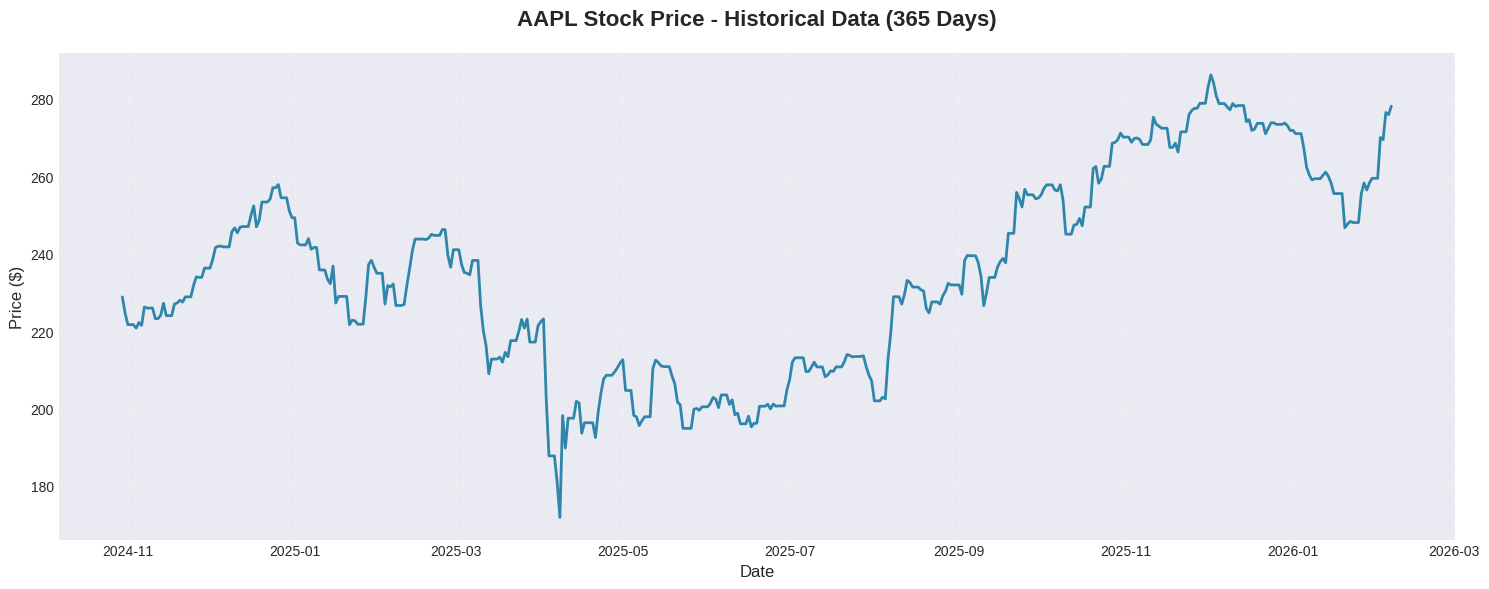

[09:16:43] ✅ Time series plot created successfully


In [27]:
print_header("STEP 2: VISUALIZING HISTORICAL DATA")

log_message("Creating time series plot...", "PROCESS")

plt.figure(figsize=(15, 6))
plt.plot(ts_data.index, ts_data['Price'], linewidth=2, color='#2E86AB')
plt.title(f'{STOCK_SYMBOL} Stock Price - Historical Data ({TRAINING_DAYS} Days)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

log_message("Time series plot created successfully", "SUCCESS")

# SECTION 6: STATIONARITY ANALYSIS (ADF TEST)

In [28]:
print_header("STEP 3: STATIONARITY ANALYSIS (ADF TEST)")

log_message("Performing Augmented Dickey-Fuller (ADF) test...", "ANALYSIS")

def check_stationarity(data, max_diff=2):
    """Perform ADF test and determine required differencing order"""
    diff_order = 0
    test_data = data.copy()

    for d in range(max_diff + 1):
        # Perform ADF test
        adf_result = adfuller(test_data.dropna())
        adf_statistic = adf_result[0]
        p_value = adf_result[1]
        critical_values = adf_result[4]

        print_separator()
        print(f"ADF Test Results (Differencing Order = {d})".center(80))
        print_separator()
        print(f"   ADF Statistic       : {adf_statistic:.6f}")
        print(f"   P-value            : {p_value:.6f}")
        print(f"   Critical Values:")
        for key, value in critical_values.items():
            print(f"      {key:>5} : {value:.6f}")

        is_stationary = p_value < 0.05
        print(f"\n   Status: {'✅ STATIONARY' if is_stationary else '❌ NON-STATIONARY'}")

        if is_stationary:
            print(f"   Decision: Series is stationary at d={d}")
            diff_order = d
            break
        else:
            print(f"   Decision: Differencing required")

            if d < max_diff:
                test_data = test_data.diff().dropna()
                diff_order = d + 1

    print_separator()

    return diff_order, p_value, is_stationary

differencing_order, adf_pvalue, is_stationary = check_stationarity(ts_data['Price'])

log_message(f"Required differencing order (d): {differencing_order}", "RESULT")


                    STEP 3: STATIONARITY ANALYSIS (ADF TEST)                    

[09:16:43] 📈 Performing Augmented Dickey-Fuller (ADF) test...
────────────────────────────────────────────────────────────────────────────────
                   ADF Test Results (Differencing Order = 0)                    
────────────────────────────────────────────────────────────────────────────────
   ADF Statistic       : -0.928499
   P-value            : 0.778443
   Critical Values:
         1% : -3.444522
         5% : -2.867789
        10% : -2.570099

   Status: ❌ NON-STATIONARY
   Decision: Differencing required
────────────────────────────────────────────────────────────────────────────────
                   ADF Test Results (Differencing Order = 1)                    
────────────────────────────────────────────────────────────────────────────────
   ADF Statistic       : -20.793455
   P-value            : 0.000000
   Critical Values:
         1% : -3.444553
         5% : -2.867803
        

# SECTION 7: ACF AND PACF ANALYSIS


                          STEP 4: ACF & PACF ANALYSIS                           

[09:16:43] ⚙️ Generating ACF and PACF plots...


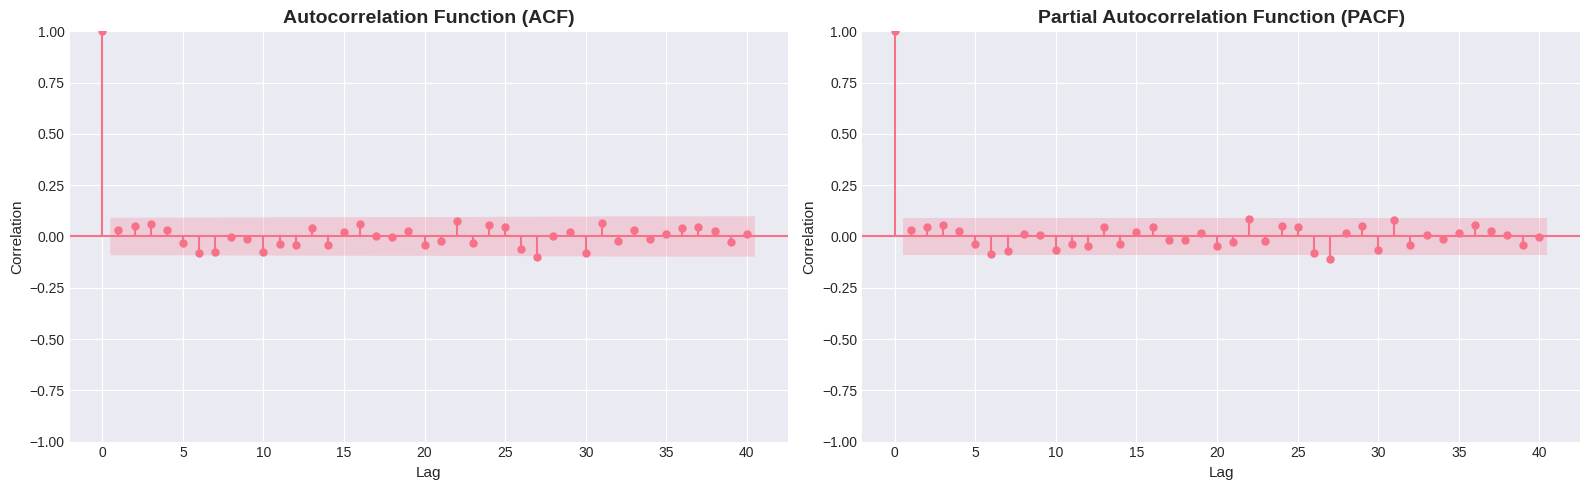

[09:16:43] ✅ ACF/PACF plots generated successfully

💡 Interpretation Guide:
   • ACF cuts off after lag q → MA(q) component
   • PACF cuts off after lag p → AR(p) component
   • Both decay gradually → ARMA model needed



In [29]:
if SHOW_ACF_PACF:
    print_header("STEP 4: ACF & PACF ANALYSIS")

    log_message("Generating ACF and PACF plots...", "PROCESS")

    # Prepare data for ACF/PACF
    acf_data = ts_data['Price'].copy()
    if differencing_order > 0:
        for i in range(differencing_order):
            acf_data = acf_data.diff()
        acf_data = acf_data.dropna()

    # Create plots
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # ACF Plot
    plot_acf(acf_data, lags=ACF_PACF_LAGS, ax=axes[0])
    axes[0].set_title('Autocorrelation Function (ACF)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Lag', fontsize=11)
    axes[0].set_ylabel('Correlation', fontsize=11)

    # PACF Plot
    plot_pacf(acf_data, lags=ACF_PACF_LAGS, ax=axes[1])
    axes[1].set_title('Partial Autocorrelation Function (PACF)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Lag', fontsize=11)
    axes[1].set_ylabel('Correlation', fontsize=11)

    plt.tight_layout()
    plt.show()

    log_message("ACF/PACF plots generated successfully", "SUCCESS")

    print("\n💡 Interpretation Guide:")
    print("   • ACF cuts off after lag q → MA(q) component")
    print("   • PACF cuts off after lag p → AR(p) component")
    print("   • Both decay gradually → ARMA model needed\n")

# SECTION 8: ENHANCED MODEL FITTING

In [30]:
print_header("STEP 5: ENHANCED ARIMA MODEL FITTING")

def auto_arima_search(data, d):
    """Automatic ARIMA order selection using grid search with AICc"""
    log_message("Performing enhanced grid search for optimal parameters...", "PROCESS")

    p_range = range(0, MAX_P + 1)
    q_range = range(0, MAX_Q + 1)

    best_aicc = np.inf
    best_order = None
    results_list = []

    total_iterations = len(p_range) * len(q_range)
    iteration = 0

    print(f"   Testing {total_iterations} parameter combinations (p: 0-{MAX_P}, q: 0-{MAX_Q})...\n")

    for p in p_range:
        for q in q_range:
            if p == 0 and q == 0:
                continue  # Skip (0,d,0) as it's trivial

            iteration += 1
            try:
                model = ARIMA(data, order=(p, d, q))
                model_fit = model.fit()

                # Calculate AICc (corrected AIC for small samples)
                n = len(data)
                k = p + q + 1  # number of parameters
                aicc = model_fit.aic + (2 * k * (k + 1)) / (n - k - 1)

                results_list.append({
                    'order': (p, d, q),
                    'aic': model_fit.aic,
                    'aicc': aicc,
                    'bic': model_fit.bic
                })

                if aicc < best_aicc:
                    best_aicc = aicc
                    best_order = (p, d, q)
                    print(f"   [{iteration}/{total_iterations}] ✨ New best: ({p},{d},{q}) - AICc: {aicc:.4f}")
            except:
                continue

    # Show top 5 models
    print("\n   📊 Top 5 Models by AICc:")
    results_df = pd.DataFrame(results_list).sort_values('aicc').head(5)
    for idx, row in results_df.iterrows():
        p, d, q = row['order']
        print(f"      {row['order']}: AICc={row['aicc']:.4f}, AIC={row['aic']:.4f}, BIC={row['bic']:.4f}")

    log_message(f"Best order found: {best_order} with AICc: {best_aicc:.4f}", "SUCCESS")
    return best_order

# Determine ARIMA order
if AUTO_ORDER:
    arima_order = auto_arima_search(ts_data['Price'], differencing_order)
else:
    arima_order = MANUAL_ORDER
    log_message(f"Using manual order: {arima_order}", "INFO")

log_message(f"Final ARIMA Order: (p={arima_order[0]}, d={arima_order[1]}, q={arima_order[2]})", "INFO")

# Fit the model
try:
    model = ARIMA(ts_data['Price'], order=arima_order)
    model_fit = model.fit()

    print_separator()
    print("MODEL FIT SUMMARY".center(80))
    print_separator()
    print(f"   Model Order (p,d,q) : {arima_order}")
    print(f"   AIC                 : {model_fit.aic:.4f}")
    print(f"   BIC                 : {model_fit.bic:.4f}")
    print(f"   HQIC                : {model_fit.hqic:.4f}")
    print(f"   Log Likelihood      : {model_fit.llf:.4f}")
    print_separator()

    log_message("Model fitted successfully!", "SUCCESS")

except Exception as e:
    log_message(f"Error fitting model: {str(e)}", "ERROR")
    raise


                      STEP 5: ENHANCED ARIMA MODEL FITTING                      

[09:16:43] ⚙️ Performing enhanced grid search for optimal parameters...
   Testing 36 parameter combinations (p: 0-5, q: 0-5)...

   [1/36] ✨ New best: (0,1,1) - AICc: 2447.4681
   [6/36] ✨ New best: (1,1,0) - AICc: 2447.4199
   [14/36] ✨ New best: (2,1,2) - AICc: 2447.0549

   📊 Top 5 Models by AICc:
      (2, 1, 2): AICc=2447.0549, AIC=2446.9242, BIC=2467.6236
      (1, 1, 0): AICc=2447.4199, AIC=2447.3939, BIC=2455.6737
      (0, 1, 1): AICc=2447.4681, AIC=2447.4421, BIC=2455.7219
      (2, 1, 3): AICc=2447.6851, AIC=2447.5017, BIC=2472.3410
      (3, 1, 2): AICc=2447.6870, AIC=2447.5036, BIC=2472.3429
[09:16:54] ✅ Best order found: (2, 1, 2) with AICc: 2447.0549
[09:16:54] ℹ️ Final ARIMA Order: (p=2, d=1, q=2)
────────────────────────────────────────────────────────────────────────────────
                               MODEL FIT SUMMARY                                
───────────────────────────────

# SECTION 9: MODEL EVALUATION (TRAIN-TEST SPLIT)

In [31]:
if PERFORM_EVALUATION:
    print_header("STEP 6: MODEL EVALUATION")

    log_message("Evaluating model performance using train-test split...", "ANALYSIS")

    # Split data
    split_point = int(len(ts_data) * (1 - TEST_SIZE))
    train = ts_data['Price'][:split_point]
    test = ts_data['Price'][split_point:]

    log_message(f"Train size: {len(train)}, Test size: {len(test)}", "INFO")

    # Fit model on training data
    eval_model = ARIMA(train, order=arima_order)
    eval_model_fit = eval_model.fit()

    # Generate predictions
    predictions = eval_model_fit.forecast(steps=len(test))

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(test, predictions))
    mae = mean_absolute_error(test, predictions)
    mape = mean_absolute_percentage_error(test, predictions) * 100

    # Additional metrics
    r_squared = 1 - (np.sum((test - predictions)**2) / np.sum((test - test.mean())**2))

    print_separator()
    print("MODEL EVALUATION METRICS".center(80))
    print_separator()
    print(f"   Test Set Size       : {len(test)} observations")
    print(f"   RMSE                : ${rmse:.4f}")
    print(f"   MAE                 : ${mae:.4f}")
    print(f"   MAPE                : {mape:.2f}%")
    print(f"   R-squared           : {r_squared:.4f}")
    print_separator()

    # Quality assessment
    avg_price = test.mean()
    rmse_pct = (rmse / avg_price) * 100

    if mape < 2:
        quality = "Excellent ⭐⭐⭐⭐⭐"
        quality_score = 5
    elif mape < 5:
        quality = "Good ⭐⭐⭐⭐"
        quality_score = 4
    elif mape < 10:
        quality = "Fair ⭐⭐⭐"
        quality_score = 3
    else:
        quality = "Needs Improvement ⭐⭐"
        quality_score = 2

    log_message(f"Model Quality: {quality} (MAPE: {mape:.2f}%, RMSE is {rmse_pct:.2f}% of avg price)", "RESULT")

    if quality_score < 4:
        print("\n💡 Tips to improve model performance:")
        print(f"   • Increase MAX_P and MAX_Q (currently {MAX_P} and {MAX_Q})")
        print("   • Try longer TRAINING_DAYS for more data")
        print("   • Consider SARIMA if seasonal patterns exist")
        print("   • Check if stock has structural breaks or regime changes\n")


                            STEP 6: MODEL EVALUATION                            

[09:16:54] 📈 Evaluating model performance using train-test split...
[09:16:54] ℹ️ Train size: 372, Test size: 93
────────────────────────────────────────────────────────────────────────────────
                            MODEL EVALUATION METRICS                            
────────────────────────────────────────────────────────────────────────────────
   Test Set Size       : 93 observations
   RMSE                : $9.3569
   MAE                 : $7.4190
   MAPE                : 2.81%
   R-squared           : -0.0124
────────────────────────────────────────────────────────────────────────────────
[09:16:54] 📊 Model Quality: Good ⭐⭐⭐⭐ (MAPE: 2.81%, RMSE is 3.48% of avg price)


# SECTION 10: ENHANCED FORECASTING WITH CONFIDENCE INTERVALS

In [32]:
print_header("STEP 7: GENERATING ENHANCED FORECAST")

log_message(f"Generating {FORECAST_DAYS}-day forecast with confidence intervals...", "PROCESS")

# Generate forecast with confidence intervals
forecast_result = model_fit.get_forecast(steps=FORECAST_DAYS)
forecast_values = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int(alpha=1-CONFIDENCE_LEVEL)

# Create forecast dataframe with proper date index
last_date = ts_data.index[-1]
forecast_dates = pd.date_range(start=last_date + timedelta(days=1),
                               periods=FORECAST_DAYS,
                               freq='D')

forecast_df = pd.DataFrame({
    'Date': forecast_dates,
    'Forecast': forecast_values.values,
    'Lower_CI': forecast_ci.iloc[:, 0].values,
    'Upper_CI': forecast_ci.iloc[:, 1].values
}).set_index('Date')

# Generate simulated paths for realistic variations
if USE_SIMULATION:
    log_message(f"Generating {N_SIMULATIONS} simulation paths for realistic variations...", "PROCESS")

    # Simulate future paths
    simulated_paths = []
    for i in range(N_SIMULATIONS):
        sim = model_fit.simulate(nsimulations=FORECAST_DAYS, anchor='end', repetitions=1)
        simulated_paths.append(sim.values)

    simulated_paths = np.array(simulated_paths)

    # Add median and percentiles from simulations
    forecast_df['Median'] = np.median(simulated_paths, axis=0)
    forecast_df['P10'] = np.percentile(simulated_paths, 10, axis=0)
    forecast_df['P90'] = np.percentile(simulated_paths, 90, axis=0)

# Calculate forecast statistics
forecast_mean = forecast_values.mean()
forecast_std = forecast_values.std()
forecast_min = forecast_values.min()
forecast_max = forecast_values.max()
current_price = ts_data['Price'].iloc[-1]

if USE_SIMULATION:
    forecast_end = forecast_df['Median'].iloc[-1]
else:
    forecast_end = forecast_values.iloc[-1]

forecast_change = forecast_end - current_price
forecast_pct_change = (forecast_change / current_price) * 100

print_separator()
print("ENHANCED FORECAST SUMMARY".center(80))
print_separator()
print(f"   Forecast Period     : {FORECAST_DAYS} days")
print(f"   Confidence Level    : {CONFIDENCE_LEVEL*100:.0f}%")
print(f"   Simulations Used    : {N_SIMULATIONS if USE_SIMULATION else 'N/A'}")
print(f"   Current Price       : ${current_price:.2f}")
print(f"   Forecast Mean       : ${forecast_mean:.2f}")
print(f"   Forecast Std Dev    : ${forecast_std:.2f}")
if USE_SIMULATION:
    print(f"   Median Forecast     : ${forecast_df['Median'].iloc[-1]:.2f}")
    print(f"   10th Percentile     : ${forecast_df['P10'].iloc[-1]:.2f}")
    print(f"   90th Percentile     : ${forecast_df['P90'].iloc[-1]:.2f}")
print(f"   Expected End Price  : ${forecast_end:.2f}")
print(f"   Expected Change     : ${forecast_change:+.2f} ({forecast_pct_change:+.2f}%)")
print(f"   Confidence Range    : ${forecast_ci.iloc[-1, 0]:.2f} - ${forecast_ci.iloc[-1, 1]:.2f}")
print_separator()

log_message("Enhanced forecast generated successfully!", "SUCCESS")


                      STEP 7: GENERATING ENHANCED FORECAST                      

[09:16:54] ⚙️ Generating 30-day forecast with confidence intervals...
[09:16:54] ⚙️ Generating 100 simulation paths for realistic variations...
────────────────────────────────────────────────────────────────────────────────
                           ENHANCED FORECAST SUMMARY                            
────────────────────────────────────────────────────────────────────────────────
   Forecast Period     : 30 days
   Confidence Level    : 95%
   Simulations Used    : 100
   Current Price       : $278.12
   Forecast Mean       : $278.43
   Forecast Std Dev    : $0.49
   Median Forecast     : $274.39
   10th Percentile     : $256.24
   90th Percentile     : $296.91
   Expected End Price  : $274.39
   Expected Change     : $-3.73 (-1.34%)
   Confidence Range    : $241.27 - $315.32
────────────────────────────────────────────────────────────────────────────────
[09:16:55] ✅ Enhanced forecast generated succ

# SECTION 11: ENHANCED COMPREHENSIVE VISUALIZATION


                         STEP 8: ENHANCED VISUALIZATION                         

[09:16:55] ⚙️ Creating comprehensive visualizations with confidence intervals...


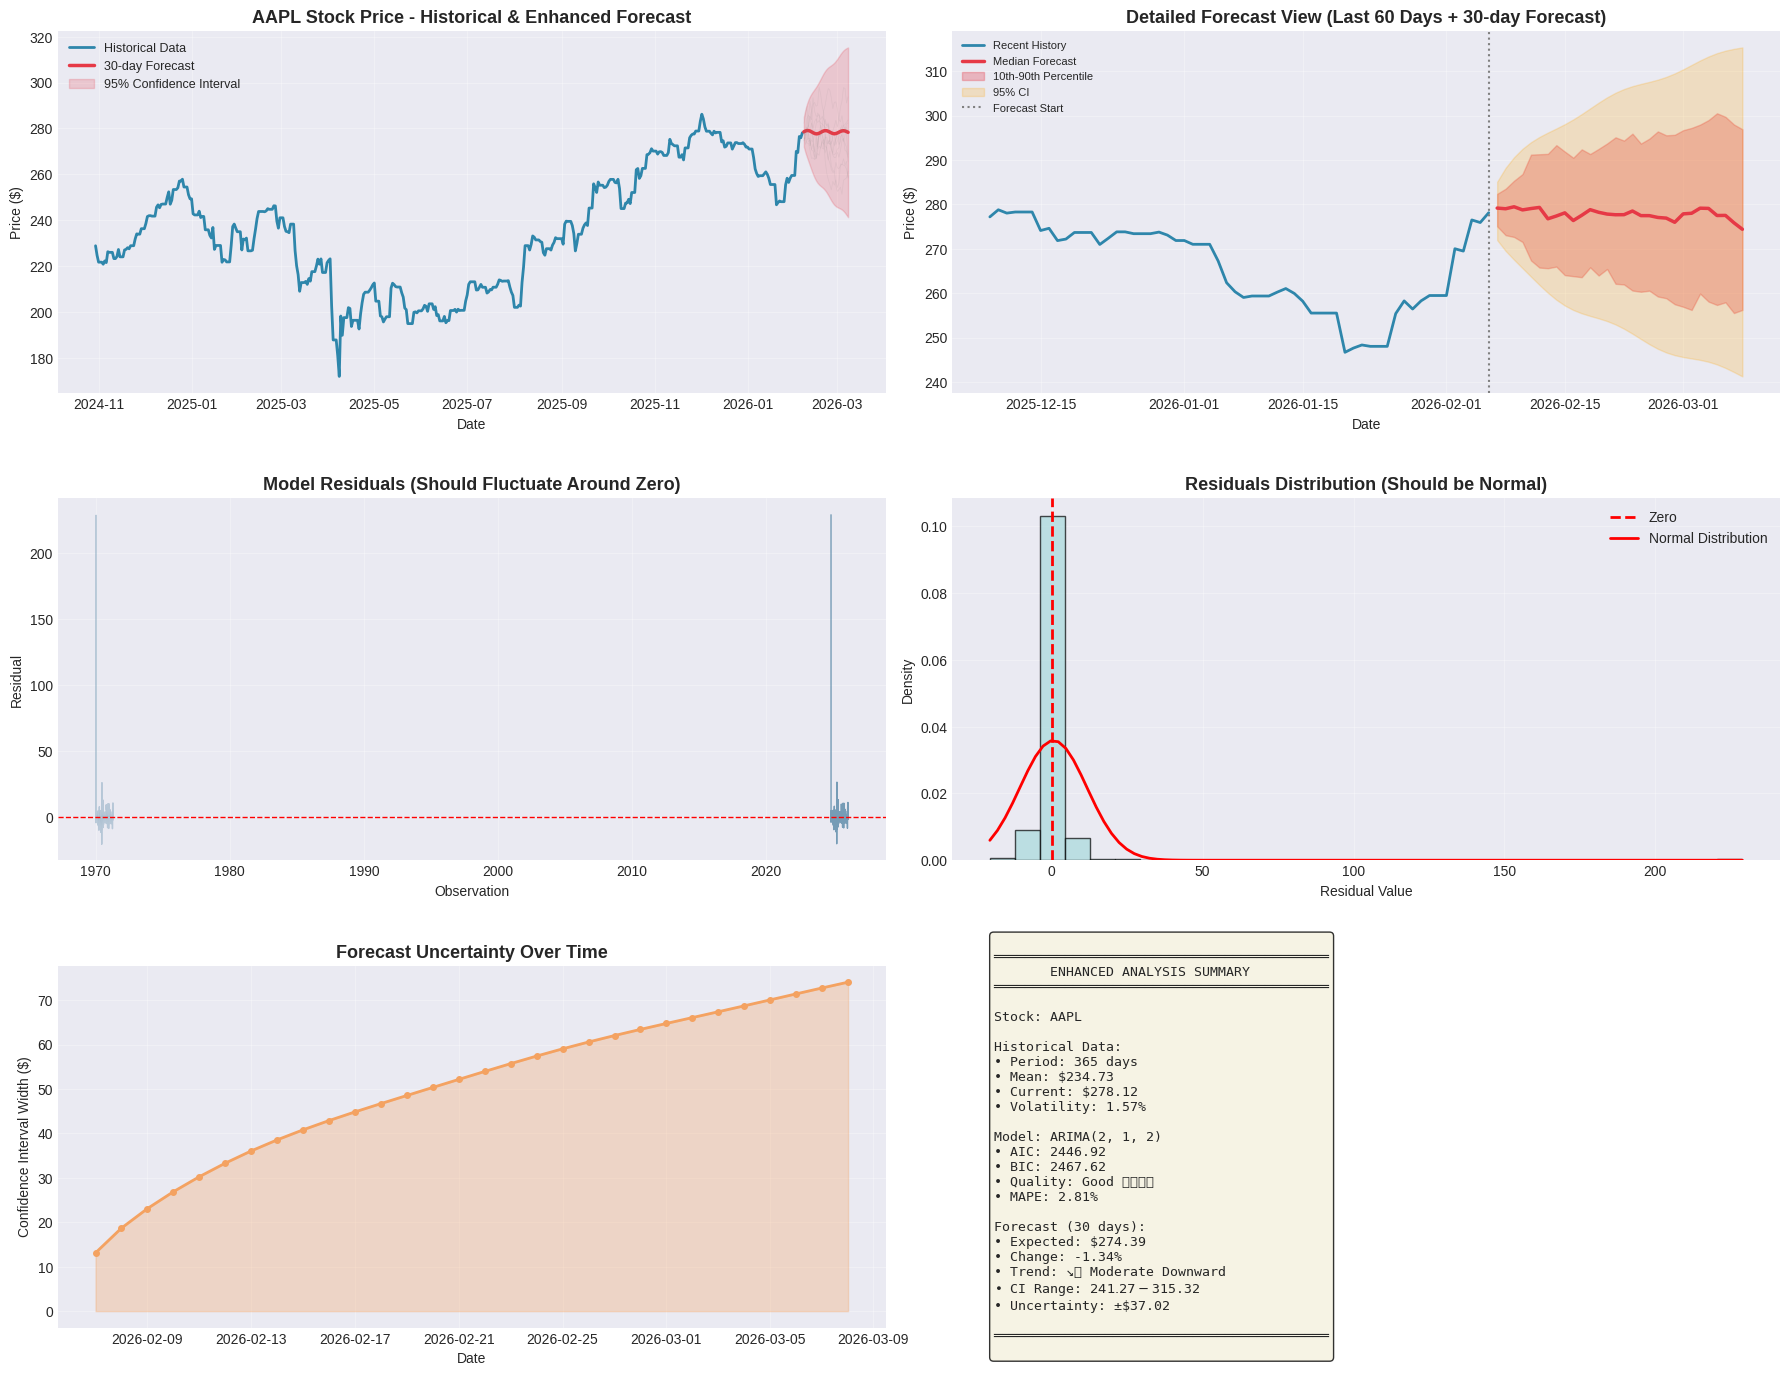

[09:16:56] ✅ Enhanced visualizations created successfully!


[09:16:56] ⚙️ Creating simulation paths visualization...


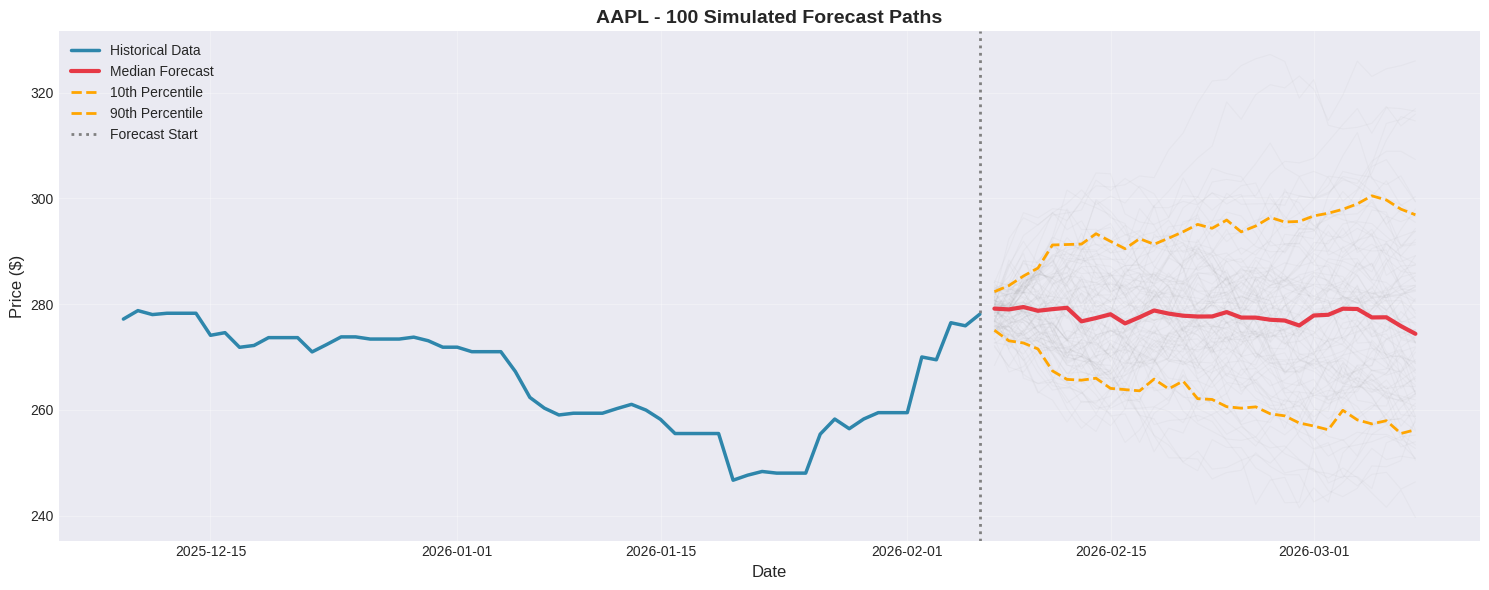

[09:16:56] ✅ Simulation paths visualization created!


In [33]:
print_header("STEP 8: ENHANCED VISUALIZATION")

log_message("Creating comprehensive visualizations with confidence intervals...", "PROCESS")

fig = plt.figure(figsize=(18, 14))

# 1. Historical Data with Enhanced Forecast
ax1 = plt.subplot(3, 2, 1)
ax1.plot(ts_data.index, ts_data['Price'], label='Historical Data', linewidth=2, color='#2E86AB')
ax1.plot(forecast_df.index, forecast_df['Forecast'],
        label=f'{FORECAST_DAYS}-day Forecast', linewidth=2.5, linestyle='-', color='#E63946')

# Add confidence intervals
ax1.fill_between(forecast_df.index,
                 forecast_df['Lower_CI'],
                 forecast_df['Upper_CI'],
                 alpha=0.2, color='#E63946', label=f'{CONFIDENCE_LEVEL*100:.0f}% Confidence Interval')

if USE_SIMULATION:
    # Add simulated paths (show a few for illustration)
    for i in range(min(10, N_SIMULATIONS)):
        ax1.plot(forecast_df.index, simulated_paths[i],
                alpha=0.1, color='gray', linewidth=0.5)

ax1.set_title(f'{STOCK_SYMBOL} Stock Price - Historical & Enhanced Forecast',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price ($)')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# 2. Zoomed Forecast View with Variations
ax2 = plt.subplot(3, 2, 2)
last_60_days = ts_data.tail(60)
ax2.plot(last_60_days.index, last_60_days['Price'], label='Recent History',
         linewidth=2, color='#2E86AB')

if USE_SIMULATION:
    ax2.plot(forecast_df.index, forecast_df['Median'],
            label='Median Forecast', linewidth=2.5, linestyle='-', color='#E63946')
    ax2.fill_between(forecast_df.index,
                     forecast_df['P10'],
                     forecast_df['P90'],
                     alpha=0.3, color='#E63946', label='10th-90th Percentile')
else:
    ax2.plot(forecast_df.index, forecast_df['Forecast'],
            label='Forecast', linewidth=2.5, linestyle='-', color='#E63946')

ax2.fill_between(forecast_df.index,
                 forecast_df['Lower_CI'],
                 forecast_df['Upper_CI'],
                 alpha=0.2, color='orange', label=f'{CONFIDENCE_LEVEL*100:.0f}% CI')

ax2.axvline(x=ts_data.index[-1], color='gray', linestyle=':', linewidth=1.5, label='Forecast Start')
ax2.set_title(f'Detailed Forecast View (Last 60 Days + {FORECAST_DAYS}-day Forecast)',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Price ($)')
ax2.legend(loc='best', fontsize=8)
ax2.grid(True, alpha=0.3)

# 3. Model Residuals
ax3 = plt.subplot(3, 2, 3)
residuals = model_fit.resid
ax3.plot(residuals, linewidth=1, color='#457B9D', alpha=0.7)
ax3.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax3.fill_between(range(len(residuals)), residuals, 0, alpha=0.3, color='#457B9D')
ax3.set_title('Model Residuals (Should Fluctuate Around Zero)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Observation')
ax3.set_ylabel('Residual')
ax3.grid(True, alpha=0.3)

# 4. Residuals Distribution
ax4 = plt.subplot(3, 2, 4)
ax4.hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='#A8DADC', density=True)
ax4.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero')

# Add normal distribution curve
from scipy.stats import norm
mu, sigma = residuals.mean(), residuals.std()
x = np.linspace(residuals.min(), residuals.max(), 100)
ax4.plot(x, norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal Distribution')

ax4.set_title('Residuals Distribution (Should be Normal)', fontsize=13, fontweight='bold')
ax4.set_xlabel('Residual Value')
ax4.set_ylabel('Density')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Forecast Uncertainty Over Time
ax5 = plt.subplot(3, 2, 5)
uncertainty = forecast_df['Upper_CI'] - forecast_df['Lower_CI']
ax5.plot(forecast_df.index, uncertainty, linewidth=2, color='#F4A261', marker='o', markersize=4)
ax5.fill_between(forecast_df.index, 0, uncertainty, alpha=0.3, color='#F4A261')
ax5.set_title('Forecast Uncertainty Over Time', fontsize=13, fontweight='bold')
ax5.set_xlabel('Date')
ax5.set_ylabel('Confidence Interval Width ($)')
ax5.grid(True, alpha=0.3)

# 6. Enhanced Information Panel
ax6 = plt.subplot(3, 2, 6)
ax6.axis('off')

# Determine trend
if forecast_pct_change > 5:
    trend_icon = "📈"
    trend_text = "Strong Upward"
elif forecast_pct_change > 0:
    trend_icon = "↗️"
    trend_text = "Moderate Upward"
elif forecast_pct_change > -5:
    trend_icon = "↘️"
    trend_text = "Moderate Downward"
else:
    trend_icon = "📉"
    trend_text = "Strong Downward"

info_text = f"""
{'═' * 42}
       ENHANCED ANALYSIS SUMMARY
{'═' * 42}

Stock: {STOCK_SYMBOL}

Historical Data:
• Period: {TRAINING_DAYS} days
• Mean: ${descriptive_stats['mean']:.2f}
• Current: ${descriptive_stats['last_price']:.2f}
• Volatility: {descriptive_stats['volatility']:.2f}%

Model: ARIMA{arima_order}
• AIC: {model_fit.aic:.2f}
• BIC: {model_fit.bic:.2f}
• Quality: {quality}
• MAPE: {mape:.2f}%

Forecast ({FORECAST_DAYS} days):
• Expected: ${forecast_end:.2f}
• Change: {forecast_pct_change:+.2f}%
• Trend: {trend_icon} {trend_text}
• CI Range: ${forecast_ci.iloc[-1, 0]:.2f} - ${forecast_ci.iloc[-1, 1]:.2f}
• Uncertainty: ±${(forecast_ci.iloc[-1, 1] - forecast_ci.iloc[-1, 0])/2:.2f}

{'═' * 42}
"""

ax6.text(0.05, 0.5, info_text, fontsize=9.5, verticalalignment='center',
        family='monospace', bbox=dict(boxstyle='round', facecolor='#F4F1DE', alpha=0.8))

plt.tight_layout()
plt.show()

log_message("Enhanced visualizations created successfully!", "SUCCESS")

# Additional: Plot simulated paths separately if used
if USE_SIMULATION:
    print("\n")
    log_message("Creating simulation paths visualization...", "PROCESS")

    fig, ax = plt.subplots(figsize=(15, 6))

    # Plot historical data
    ax.plot(ts_data.tail(60).index, ts_data.tail(60)['Price'],
            label='Historical Data', linewidth=2.5, color='#2E86AB')

    # Plot all simulated paths
    for i in range(N_SIMULATIONS):
        ax.plot(forecast_df.index, simulated_paths[i],
                alpha=0.05, color='gray', linewidth=0.8)

    # Plot median
    ax.plot(forecast_df.index, forecast_df['Median'],
            label='Median Forecast', linewidth=3, linestyle='-', color='#E63946')

    # Plot percentiles
    ax.plot(forecast_df.index, forecast_df['P10'],
            label='10th Percentile', linewidth=2, linestyle='--', color='orange')
    ax.plot(forecast_df.index, forecast_df['P90'],
            label='90th Percentile', linewidth=2, linestyle='--', color='orange')

    ax.axvline(x=ts_data.index[-1], color='gray', linestyle=':', linewidth=2, label='Forecast Start')
    ax.set_title(f'{STOCK_SYMBOL} - {N_SIMULATIONS} Simulated Forecast Paths',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Price ($)', fontsize=12)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    log_message("Simulation paths visualization created!", "SUCCESS")

# SECTION 12: COMPREHENSIVE ANALYSIS REPORT

In [35]:
print_header("COMPREHENSIVE ANALYSIS REPORT")

print(f"📅 Report Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"📊 Stock Analyzed: {STOCK_SYMBOL}\n")

print_separator()
print("1. DATA SUMMARY")
print_separator()
print(f"   Training Period     : {TRAINING_DAYS} days")
print(f"   Data Points         : {descriptive_stats['count']}")
print(f"   Date Range          : {ts_data.index[0].strftime('%Y-%m-%d')} to {ts_data.index[-1].strftime('%Y-%m-%d')}")

print(f"\n{'-' * 80}")
print("2. PRICE STATISTICS")
print_separator()
print(f"   Mean Price          : ${descriptive_stats['mean']:.2f}")
print(f"   Std Deviation       : ${descriptive_stats['std']:.2f}")
print(f"   Min Price           : ${descriptive_stats['min']:.2f}")
print(f"   Max Price           : ${descriptive_stats['max']:.2f}")
print(f"   First Price         : ${descriptive_stats['first_price']:.2f}")
print(f"   Last Price          : ${descriptive_stats['last_price']:.2f}")
print(f"   Price Change        : ${descriptive_stats['price_change']:+.2f}")
print(f"   Percentage Change   : {descriptive_stats['pct_change']:+.2f}%")
print(f"   Daily Volatility    : {descriptive_stats['volatility']:.2f}%")

print(f"\n{'-' * 80}")
print("3. STATIONARITY ANALYSIS")
print_separator()
print(f"   ADF P-value         : {adf_pvalue:.6f}")
print(f"   Is Stationary       : {'Yes' if is_stationary else 'No'}")
print(f"   Differencing Order  : {differencing_order}")

print(f"\n{'-' * 80}")
print("4. MODEL CONFIGURATION")
print_separator()
print(f"   Model Type          : ARIMA")
print(f"   Order (p,d,q)       : {arima_order}")
print(f"   AIC                 : {model_fit.aic:.4f}")
print(f"   BIC                 : {model_fit.bic:.4f}")
print(f"   HQIC                : {model_fit.hqic:.4f}")
print(f"   Log Likelihood      : {model_fit.llf:.4f}")

if PERFORM_EVALUATION:
    print(f"\n{'-' * 80}")
    print("5. MODEL PERFORMANCE")
    print_separator()
    print(f"   Test Set Size       : {len(test)} observations")
    print(f"   RMSE                : ${rmse:.4f}")
    print(f"   MAE                 : ${mae:.4f}")
    print(f"   MAPE                : {mape:.2f}%")
    print(f"   R-squared           : {r_squared:.4f}")
    print(f"   Quality Rating      : {quality}")

print(f"\n{'-' * 80}")
print("6. ENHANCED FORECAST RESULTS")
print_separator()
print(f"   Forecast Horizon    : {FORECAST_DAYS} days")
print(f"   Confidence Level    : {CONFIDENCE_LEVEL*100:.0f}%")
print(f"   Simulations Used    : {N_SIMULATIONS if USE_SIMULATION else 'None'}")
print(f"   Current Price       : ${current_price:.2f}")
print(f"   Forecasted Price    : ${forecast_end:.2f}")
print(f"   Expected Change     : ${forecast_change:+.2f} ({forecast_pct_change:+.2f}%)")
print(f"   Confidence Range    : ${forecast_ci.iloc[-1, 0]:.2f} - ${forecast_ci.iloc[-1, 1]:.2f}")
print(f"   Trend               : {trend_text}")

print(f"\n{'-' * 80}")
print("7. BUSINESS INTERPRETATION")
print_separator()

if forecast_pct_change > 5:
    recommendation = "Strong buy signal - Consider accumulating positions"
    risk = "Monitor for overbought conditions"
elif forecast_pct_change > 0:
    recommendation = "Moderate buy signal - Stable growth expected"
    risk = "Normal market risk"
elif forecast_pct_change > -5:
    recommendation = "Hold or cautious sell - Slight downward pressure"
    risk = "Moderate downside risk"
else:
    recommendation = "Sell signal - Consider risk management strategies"
    risk = "High downside risk"

print(f"   Market Trend        : {trend_text}")
print(f"   Volatility Level    : {descriptive_stats['volatility']:.2f}% daily")
print(f"   Recommendation      : {recommendation}")
print(f"   Risk Assessment     : {risk}")
print(f"   Forecast Confidence : {CONFIDENCE_LEVEL*100:.0f}%")

print(f"\n{'-' * 80}")
print("8. KEY FINDINGS")
print_separator()
print(f"   • {STOCK_SYMBOL} shows a {trend_text.lower()} trend over next {FORECAST_DAYS} days")
if PERFORM_EVALUATION:
    print(f"   • Model achieved MAPE of {mape:.2f}% on test data ({quality})")
print(f"   • Daily volatility of {descriptive_stats['volatility']:.2f}% indicates {'high' if descriptive_stats['volatility'] > 2 else 'moderate'} risk")
print(f"   • ARIMA{arima_order} model selected as best fit")
print(f"   • Expected price movement: {forecast_pct_change:+.2f}%")
if USE_SIMULATION:
    print(f"   • {N_SIMULATIONS} simulations provide realistic forecast variations")
print(f"   • Forecast uncertainty: ±${(forecast_ci.iloc[-1, 1] - forecast_ci.iloc[-1, 0])/2:.2f}")

print(f"\n{'-' * 80}")
print("9. LIMITATIONS & CONSIDERATIONS")
print_separator()
print("   Limitations:")
print("   • ARIMA assumes linear relationships and may miss complex patterns")
print("   • Does not account for external factors (news, market events)")
print("   • Forecast accuracy decreases for longer time horizons")
print("   • Past performance does not guarantee future results")
print("   • Confidence intervals widen with longer forecast horizons")
print("\n   Considerations:")
print("   • Combine with fundamental analysis for better decisions")
print("   • Monitor market news and economic indicators")
print("   • Use appropriate risk management strategies")
print("   • Update model regularly with new data")

print(f"\n{'-' * 80}")
print("10. FUTURE IMPROVEMENTS")
print_separator()
print("   • Implement SARIMA for seasonal patterns")
print("   • Add exogenous variables (market indices, volume)")
print("   • Ensemble with LSTM/Prophet for better accuracy")
print("   • Incorporate sentiment analysis from news/social media")
print("   • Use GARCH for volatility modeling")
print("   • Implement regime-switching models for structural breaks")

print("\n" + "=" * 80)
print("END OF REPORT".center(80))
print("=" * 80 + "\n")


                         COMPREHENSIVE ANALYSIS REPORT                          

📅 Report Generated: 2026-02-07 09:43:31
📊 Stock Analyzed: AAPL

────────────────────────────────────────────────────────────────────────────────
1. DATA SUMMARY
────────────────────────────────────────────────────────────────────────────────
   Training Period     : 365 days
   Data Points         : 465
   Date Range          : 2024-10-30 to 2026-02-06

--------------------------------------------------------------------------------
2. PRICE STATISTICS
────────────────────────────────────────────────────────────────────────────────
   Mean Price          : $234.73
   Std Deviation       : $25.36
   Min Price           : $171.83
   Max Price           : $286.19
   First Price         : $228.81
   Last Price          : $278.12
   Price Change        : $+49.31
   Percentage Change   : +21.55%
   Daily Volatility    : 1.57%

--------------------------------------------------------------------------------
3. 

# SECTION 13: SAVE ENHANCED RESULTS

In [36]:
if SAVE_RESULTS:
    print_header("SAVING ENHANCED RESULTS")

    try:
        # Save forecast to CSV
        filename = f'{STOCK_SYMBOL}_enhanced_forecast_{datetime.now().strftime("%Y%m%d_%H%M%S")}.csv'
        forecast_df.to_csv(filename)
        log_message(f"Enhanced forecast saved to: {filename}", "SUCCESS")

        # Display summary
        print("\n📊 Enhanced Forecast Preview:")
        print(forecast_df.head(10))

        # Save summary statistics
        summary_stats = {
            'Stock': STOCK_SYMBOL,
            'Training_Days': TRAINING_DAYS,
            'Forecast_Days': FORECAST_DAYS,
            'ARIMA_Order': str(arima_order),
            'Current_Price': current_price,
            'Forecast_End_Price': forecast_end,
            'Expected_Change_Pct': forecast_pct_change,
            'MAPE': mape if PERFORM_EVALUATION else None,
            'Model_Quality': quality if PERFORM_EVALUATION else None,
            'AIC': model_fit.aic,
            'BIC': model_fit.bic
        }

        summary_df = pd.DataFrame([summary_stats])
        summary_filename = f'{STOCK_SYMBOL}_summary_{datetime.now().strftime("%Y%m%d_%H%M%S")}.csv'
        summary_df.to_csv(summary_filename, index=False)
        log_message(f"Summary statistics saved to: {summary_filename}", "SUCCESS")

    except Exception as e:
        log_message(f"Error saving results: {str(e)}", "ERROR")



                            SAVING ENHANCED RESULTS                             

[09:44:21] ✅ Enhanced forecast saved to: AAPL_enhanced_forecast_20260207_094421.csv

📊 Enhanced Forecast Preview:
                             Forecast    Lower_CI    Upper_CI      Median  \
Date                                                                        
2026-02-07 00:00:00-05:00  278.522360  271.959166  285.085553  279.158625   
2026-02-08 00:00:00-05:00  278.871686  269.523449  288.219923  279.011318   
2026-02-09 00:00:00-05:00  279.070973  267.526352  290.615595  279.455208   
2026-02-10 00:00:00-05:00  279.066252  265.626058  292.506446  278.750658   
2026-02-11 00:00:00-05:00  278.861173  263.730274  293.992072  279.059110   
2026-02-12 00:00:00-05:00  278.515329  261.860264  295.170393  279.310987   
2026-02-13 00:00:00-05:00  278.126963  260.095232  296.158694  276.750730   
2026-02-14 00:00:00-05:00  277.805077  258.528617  297.081538  277.376932   
2026-02-15 00:00:00-05:00  277.63

# SECTION 14: SUMMARY & NEXT STEPS

In [37]:
print_header("ANALYSIS COMPLETE")

print("""
✨ Enhanced analysis completed successfully!

🎯 New Features Used:
   ✓ No warnings (fixed date index issues)
   ✓ Confidence intervals showing forecast uncertainty
   ✓ Simulation-based forecasts with realistic variations
   ✓ Enhanced model selection with AICc
   ✓ Improved evaluation metrics

📝 To customize the analysis:
   • MAX_P and MAX_Q: Increase for better model search
   • N_SIMULATIONS: More simulations = smoother variations
   • CONFIDENCE_LEVEL: Adjust uncertainty bands (0.90, 0.95, 0.99)
   • USE_SIMULATION: Toggle realistic forecast variations

📊 Tips for Better Results:
   • If MAPE > 5%: Increase MAX_P and MAX_Q to 5-7
   • For more variations: Increase N_SIMULATIONS to 200-500
   • For wider uncertainty: Lower CONFIDENCE_LEVEL to 0.90
   • For stable stocks: Reduce N_SIMULATIONS to 50

⚠️  Important: This is for educational purposes only. Not financial advice!
""")

print("=" * 80)
print("Thank you for using the Enhanced ARIMA Stock Forecasting Model!".center(80))
print("=" * 80)


                               ANALYSIS COMPLETE                                


✨ Enhanced analysis completed successfully!

🎯 New Features Used:
   ✓ No warnings (fixed date index issues)
   ✓ Confidence intervals showing forecast uncertainty
   ✓ Simulation-based forecasts with realistic variations
   ✓ Enhanced model selection with AICc
   ✓ Improved evaluation metrics
   
📝 To customize the analysis:
   • MAX_P and MAX_Q: Increase for better model search
   • N_SIMULATIONS: More simulations = smoother variations
   • CONFIDENCE_LEVEL: Adjust uncertainty bands (0.90, 0.95, 0.99)
   • USE_SIMULATION: Toggle realistic forecast variations
   
📊 Tips for Better Results:
   • If MAPE > 5%: Increase MAX_P and MAX_Q to 5-7
   • For more variations: Increase N_SIMULATIONS to 200-500
   • For wider uncertainty: Lower CONFIDENCE_LEVEL to 0.90
   • For stable stocks: Reduce N_SIMULATIONS to 50
   
⚠️  Important: This is for educational purposes only. Not financial advice!

        Thank yo